In [1]:
import os
import sys
# block warnings from printing
import warnings
warnings.filterwarnings('ignore')
warnings.simplefilter('ignore')

import xarray as xr
xr.set_options(keep_attrs=True)
import numpy as np
np.seterr(divide='ignore', invalid='ignore')
from scipy.ndimage import gaussian_filter1d
import pyproj

import cartopy
cartopy.config['data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
cartopy.config['pre_existing_data_dir'] = "/discover/nobackup/projects/jh_tutorials/JH_examples/JH_datafiles/Cartopy"
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
from shapely.ops import transform
from shapely.geometry import LineString
import regionmask

import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.patches as patches
from matplotlib.patches import Polygon
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.ticker as mticker
import matplotlib.colors as mcolors
from matplotlib import cm

# settings
%config InlineBackend.figure_format = 'retina'

# add path to custom functions
module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path+"/py_functions")
from map_plot_tools import *
from colorbar_funcs import *
from data_funcs import *
from stats_funcs import *

dpath0='/discover/nobackup/projects/giss/baldwin_nip/dmkumar'
opath='../figs'

In [2]:
def match_lat_lon_names(ds):
    for lat_name in ['y', 'latitude', 'nav_lat']:
        if (lat_name in ds.coords) and ('lat' not in ds.coords):
            ds = ds.rename({lat_name: 'lat'})
    for lon_name in ['x', 'longitude', 'nav_lon']:
        if (lon_name in ds.coords) and ('lon' not in ds.coords):
            ds = ds.rename({lon_name: 'lon'})
    return ds

def jas_seasonal_mean(ds):
    """
    Calculate seasonal mean accounting for varying month lengths
    ** assumes no leap **
    """    
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_weighted_mean = (jas * weights).sum(dim='time') / weights.sum(dim='time')
    return jas_weighted_mean

def jas_yearly_mean(ds):
    """
    Calculate jas seasonal mean for each year, accounting for varying month lengths
    ** assumes no leap **
    """ 
    jas = ds.sel(time=ds['time.month'].isin([7, 8, 9]))
    weights = jas['time'].dt.days_in_month
    jas_yearly_weighted_mean = ((jas * weights).groupby('time.year').sum(dim='time') / weights.groupby('time.year').sum(dim='time'))
    return jas_yearly_weighted_mean

def rotated_box(lon0, lat0, width, height, angle_deg):
    angle = np.deg2rad(angle_deg)

    # Half sizes
    dx = width / 2
    dy = height / 2

    # Corners relative to center
    corners = np.array([
        [-dx, -dy],
        [ dx, -dy],
        [ dx,  dy],
        [-dx,  dy]
    ])

    # Rotation matrix
    R = np.array([
        [np.cos(angle), -np.sin(angle)],
        [np.sin(angle),  np.cos(angle)]
    ])

    rotated = corners @ R.T
    rotated[:, 0] += lon0
    rotated[:, 1] += lat0

    return rotated

def regional_weighted_mean(da, region_name, regions):
    mask3d = regions.mask_3D(da)
    region_index = regions.names.index(region_name)
    masked = da.where(mask3d.sel(region=region_index))
    weights = np.cos(np.deg2rad(da.lat))
    return masked.weighted(weights).mean(("lat", "lon"))

In [4]:
models=['CAM-MPAS',
        'CAMS-CSM1-0',
        'CMCC-CM2',
        'CNRM-CM6-1',
        'EC-Earth3P',
        'ECMWF-IFS',
        'FGOALS-f3',
        'GFDL-CM4',
        'HadGEM3-GC31',
        'HiRAM-SIT',
        'INM-CM5',
        'IPSL-CM6A',
        'MPI-ESM1-2',
        'MRI-ESM2',
        'NICAM16']

lr_map = {
    'CAM-MPAS': ['CAM-MPAS-LR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0-LR'],
    'CMCC-CM2': ['CMCC-CM2-HR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1'],
    'EC-Earth3P': [],
    'ECMWF-IFS': ['ECMWF-IFS-LR'],
    'FGOALS-f3': ['FGOALS-f3-L'],
    'GFDL-CM4': ['GFDL-CM4'],
    'HadGEM3-GC31': ['HadGEM3-GC31-LM'],
    'HiRAM-SIT': [],
    'INM-CM5': ['INM-CM5-0'],
    'IPSL-CM6A': ['IPSL-CM6A-LR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-LR'],
    'MRI-ESM2': ['MRI-ESM2-0'],
    'NICAM16': [],
}

hr_map = {
    'CAM-MPAS': ['CAM-MPAS-HR'],
    'CAMS-CSM1-0': ['CAMS-CSM1-0'],
    'CMCC-CM2': ['CMCC-CM2-VHR4'],
    'CNRM-CM6-1': ['CNRM-CM6-1-HR'],
    'EC-Earth3P': ['EC-Earth3P', 'EC-Earth3P-HR'],
    'ECMWF-IFS': ['ECMWF-IFS-HR'],
    'FGOALS-f3': ['FGOALS-f3-H'],
    'GFDL-CM4': ['GFDL-CM4C192'],
    'HadGEM3-GC31': ['HadGEM3-GC31-MM', 'HadGEM3-GC31-HM'],
    'HiRAM-SIT': ['HiRAM-SIT-LR', 'HiRAM-SIT-HR'],
    'INM-CM5': ['INM-CM5-H'],
    'IPSL-CM6A': ['IPSL-CM6A-ATM-HR'],
    'MPI-ESM1-2': ['MPI-ESM1-2-HR', 'MPI-ESM1-2-XR'],
    'MRI-ESM2': ['MRI-AGCM3-2-H', 'MRI-AGCM3-2-S'],
    'NICAM16': ['NICAM16-7S', 'NICAM16-8S'],
}

# INITIAL DATA PROCESSING

- Load HighResMIP and observational data
- Calculate Jul.-Sept. seasonal mean values
- Regrid obs data to model grids
- Calculate model - obs precipitation biases and significance testing

Only needs to be run 1x. Then, generates cache files for future figure iterations.

In [5]:
## +++ LOAD HRMIP DATA +++ ##

files = {}
varn = 'pr'
case = 'highresSST-present'

for model in models:
    for cfg in lr_map[model] + hr_map[model]:
        files[cfg] = f"{dpath0}/hrmip/{case}/{varn}/{varn}.Amon.{case}.{cfg}.nc"

dat    = {'lr': {}, 'hr': {}}
dat_na = {'lr': {}, 'hr': {}}
latmin, latmax = 10, 70
lonmin, lonmax = 200, 300

print("Working on...")
for res, rmap in {'lr': lr_map, 'hr': hr_map}.items():
    for model in models:
        for cfg in rmap[model]:
            print(f"{res.upper()} -> {cfg}")
            ds = xr.open_dataset(files[cfg], chunks={'time': 12})['pr']
            ds = ds.sortby('time').sel(time=slice('1950', '2014'))
            ds = match_lat_lon_names(ds) * 86400  # mm/s → mm/day
            ds = ds.squeeze().drop_vars([c for c in ['member_id', 'dcpp_init_year'] if c in ds.coords])
            dat[res][cfg]    = ds
            dat_na[res][cfg] = ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
print("Done.")

Working on...
LR -> CAM-MPAS-LR
LR -> CAMS-CSM1-0-LR
LR -> CMCC-CM2-HR4
LR -> CNRM-CM6-1
LR -> ECMWF-IFS-LR
LR -> FGOALS-f3-L
LR -> GFDL-CM4
LR -> HadGEM3-GC31-LM
LR -> INM-CM5-0
LR -> IPSL-CM6A-LR
LR -> MPI-ESM1-2-LR
LR -> MRI-ESM2-0
HR -> CAM-MPAS-HR
HR -> CAMS-CSM1-0
HR -> CMCC-CM2-VHR4
HR -> CNRM-CM6-1-HR
HR -> EC-Earth3P
HR -> EC-Earth3P-HR
HR -> ECMWF-IFS-HR
HR -> FGOALS-f3-H
HR -> GFDL-CM4C192
HR -> HadGEM3-GC31-MM
HR -> HadGEM3-GC31-HM
HR -> HiRAM-SIT-LR
HR -> HiRAM-SIT-HR
HR -> INM-CM5-H
HR -> IPSL-CM6A-ATM-HR
HR -> MPI-ESM1-2-HR
HR -> MPI-ESM1-2-XR
HR -> MRI-AGCM3-2-H
HR -> MRI-AGCM3-2-S
HR -> NICAM16-7S
HR -> NICAM16-8S
Done.


In [10]:
## +++ LOAD OBS DATA +++ ##

#=== Precip products
obs_prods = ['imerg', 'trmm', 'gpcp', 'gpcc']

obs_files = {
    'imerg': f'{dpath0}/obs_data/prec/imerg.gn.timeseries.2001-2018.nc',
    'trmm':  f'{dpath0}/obs_data/prec/pr_TRMM-L3_v7-7A_199801-201312.nc',
    'gpcp':  f'{dpath0}/obs_data/prec/gpcp.precip.1979-2018.monthly.nc',
    'gpcc':  f'{dpath0}/obs_data/prec/gpcc.precip.mon.rate.0.25x0.25.v2020.nc',
}

obs_dat    = {prod: {} for prod in obs_prods}
obs_dat_na = {prod: {} for prod in obs_prods}

print('Working on...')
for prod in obs_prods:
    print(f"-> {prod}")
    if prod == 'imerg':
        ds = xr.open_dataset(obs_files[prod], chunks={'time': 12}).precipitation * 24  # mm/hr → mm/day
        ds = ds.transpose('time', 'lat', 'lon')
        ds.attrs['units'] = 'mm/day'
        ds.attrs['Units'] = 'mm/day'
        ds = lonFlip(ds)
    elif prod == 'trmm':
        ds = xr.open_dataset(obs_files[prod], chunks={'time': 12}).pr * 86400  # kg m-2 s-1 → mm/day
    elif prod == 'gpcp':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip
    elif prod == 'gpcc':
        ds = xr.open_dataset(obs_files[prod], chunks={}).precip.sortby("lat")
    obs_dat[prod]    = ds
    obs_dat_na[prod] = ds.sel(lat=slice(latmin, latmax), lon=slice(lonmin, lonmax))
    del ds
print('Done.\n')

#=== Topo data
etopo_full = xr.open_dataset(f'{dpath0}/topo_files/obs.etopo5.zsurf.nc').ROSE.rename({'ETOPO05_X':'lon', 'ETOPO05_Y':'lat'})
etopoNA = etopo_full.where(etopo_full>0, np.nan).sel(lat=slice(latmin,latmax), lon=slice(lonmin,lonmax))
print('Topography data loaded.')

Working on...
-> imerg
-> trmm
-> gpcp
-> gpcc
Done.
Topography data loaded.


In [11]:
## +++ Calculate Jul.-Sept. Seasonal Means +++ ##

jas_mean = {
    'lr':  {},
    'hr':  {},
    'obs': {prod: {} for prod in obs_prods},
}
ann_jas_mean = {
    'lr':  {},
    'hr':  {},
    'obs': {prod: {} for prod in obs_prods},
}

for res in ['lr', 'hr']:
    for cfg, ds in dat_na[res].items():
        jas_mean[res][cfg]     = jas_seasonal_mean(ds)
        ann_jas_mean[res][cfg] = jas_yearly_mean(ds)

for prod in obs_prods:
    jas_mean['obs'][prod]     = jas_seasonal_mean(obs_dat_na[prod])
    ann_jas_mean['obs'][prod] = jas_yearly_mean(obs_dat_na[prod])

print('Done.')

Done.


In [12]:
## +++ SIGNIFICANCE TESTING +++ ##

#=== Regrid obs to each model grid for comparison
obs_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
obs_ann_jas_mean_regrid = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

print('Regridding obs.')
for prod in obs_prods:
    for res in ['lr', 'hr']:
        for cfg, ds in dat_na[res].items():
            obs_jas_mean_regrid[prod][res][cfg] = jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)
            obs_ann_jas_mean_regrid[prod][res][cfg] = ann_jas_mean['obs'][prod].interp(lat=ds.lat, lon=ds.lon)

print('Done.\n')

#=== Significance testing
diff      = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
diff_mask = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}
ptvals    = {prod: {'lr': {}, 'hr': {}} for prod in obs_prods}

print('Significance testing for:')
for prod in obs_prods:
    print(f'\n{prod}')
    for res in ['lr', 'hr']:
        print(f'->{res}')
        for cfg in dat[res]:
            print(f'--->{cfg}')
            d, m, p = sigtest2n(ann_jas_mean[res][cfg], obs_ann_jas_mean_regrid[prod][res][cfg],
                                jas_mean[res][cfg],     obs_jas_mean_regrid[prod][res][cfg])
            diff[prod][res][cfg] = d
            diff_mask[prod][res][cfg] = m
            ptvals[prod][res][cfg] = p

print('Done.')

Regridding obs.
Done.

Significance testing for:

imerg
->lr
--->CAM-MPAS-LR
--->CAMS-CSM1-0-LR
--->CMCC-CM2-HR4
--->CNRM-CM6-1
--->ECMWF-IFS-LR
--->FGOALS-f3-L
--->GFDL-CM4
--->HadGEM3-GC31-LM
--->INM-CM5-0
--->IPSL-CM6A-LR
--->MPI-ESM1-2-LR
--->MRI-ESM2-0
->hr
--->CAM-MPAS-HR
--->CAMS-CSM1-0
--->CMCC-CM2-VHR4
--->CNRM-CM6-1-HR
--->EC-Earth3P
--->EC-Earth3P-HR
--->ECMWF-IFS-HR
--->FGOALS-f3-H
--->GFDL-CM4C192
--->HadGEM3-GC31-MM
--->HadGEM3-GC31-HM
--->HiRAM-SIT-LR
--->HiRAM-SIT-HR
--->INM-CM5-H
--->IPSL-CM6A-ATM-HR
--->MPI-ESM1-2-HR
--->MPI-ESM1-2-XR
--->MRI-AGCM3-2-H
--->MRI-AGCM3-2-S
--->NICAM16-7S
--->NICAM16-8S

trmm
->lr
--->CAM-MPAS-LR
--->CAMS-CSM1-0-LR
--->CMCC-CM2-HR4
--->CNRM-CM6-1
--->ECMWF-IFS-LR
--->FGOALS-f3-L
--->GFDL-CM4
--->HadGEM3-GC31-LM
--->INM-CM5-0
--->IPSL-CM6A-LR
--->MPI-ESM1-2-LR
--->MRI-ESM2-0
->hr
--->CAM-MPAS-HR
--->CAMS-CSM1-0
--->CMCC-CM2-VHR4
--->CNRM-CM6-1-HR
--->EC-Earth3P
--->EC-Earth3P-HR
--->ECMWF-IFS-HR
--->FGOALS-f3-H
--->GFDL-CM4C192
--->HadGEM3

# Start Here on Re-Runs

In [13]:
## +++ CREATE COMBINED DICT OF HIGH- & LOW-RES. BIASES +++ ##

# lat/lon bounds for broad NAM domain subset
ymin, ymax = 15, 45
xmin, xmax = 240, 270

# Config lists derived from lr_map/hr_map
all_cfgs = {
    'lr': [cfg for m in models for cfg in lr_map[m]],
    'hr': [cfg for m in models for cfg in hr_map[m]],
}
all_cfgs_flat = all_cfgs['lr'] + all_cfgs['hr']

# --- Cache logic ---
# Each per-config NetCDF stores bias maps for all obs products as variables and
# the full-grid longitude count as a file attribute (needed for resolution coloring).
# On re-runs: if all cache files exist, load directly and skip ALL upstream cells
cache_dir = '../hrmip/cache/'
cache_files = {cfg: os.path.join(cache_dir, f'pr_bias_{cfg}.nc') for cfg in all_cfgs_flat}
use_cache = all(os.path.exists(f) for f in cache_files.values())

if use_cache:
    print("Loading allmodels from cache...")
    allmodels = {prod: {} for prod in obs_prods}
    allmodels_res = {}
    for res in ['lr', 'hr']:
        for cfg in all_cfgs[res]:
            ds = xr.open_dataset(cache_files[cfg])
            for prod in obs_prods:
                allmodels[prod][cfg] = ds[prod]
            allmodels_res[cfg] = int(ds.attrs['nlon'])
    print("Done.")
else:
    print("Computing allmodels (cache will be written for future runs)...")
    allmodels = {prod: {} for prod in obs_prods}
    for prod in obs_prods:
        for res in ['lr', 'hr']:
            for cfg, da in diff[prod][res].items():
                allmodels[prod][cfg] = da.sel(lat=slice(ymin, ymax), lon=slice(xmin, xmax)).load()

    # Full-grid lon counts from dat (only needed on first run)
    allmodels_res = {}
    for res in ['lr', 'hr']:
        for cfg, da in dat[res].items():
            allmodels_res[cfg] = len(da.lon)

    # Save one NetCDF per config: obs-product variables + nlon attribute
    os.makedirs(cache_dir, exist_ok=True)
    for res in ['lr', 'hr']:
        for cfg in all_cfgs[res]:
            ds_out = xr.Dataset({prod: allmodels[prod][cfg] for prod in obs_prods})
            ds_out.attrs['nlon'] = allmodels_res[cfg]
            ds_out.to_netcdf(cache_files[cfg])
    print(f"Saved {len(all_cfgs_flat)} cache files to {cache_dir}")

sorted_models = {}
for prod in obs_prods:
    sorted_models[prod] = dict(sorted(allmodels[prod].items(), key=lambda item: len(item[1].coords["lon"])))

Computing allmodels (cache will be written for future runs)...
Saved 33 cache files to ../hrmip/cache/


In [14]:
## +++ GET INFO ABOUT MODEL RESOLUTIONS +++ ##

# allmodels_res: {cfg: nlon_int}, sorted by resolution ascending
allmodels_res = dict(sorted(allmodels_res.items(), key=lambda item: item[1]))

lowres_counts  = {cfg: allmodels_res[cfg] for cfg in all_cfgs['lr']}
highres_counts = {cfg: allmodels_res[cfg] for cfg in all_cfgs['hr']}

# compute medians
median_lowres = np.median(list(lowres_counts.values()))
median_highres = np.median(list(highres_counts.values()))

# compute means
mean_lowres = np.mean(list(lowres_counts.values()))
mean_highres = np.mean(list(highres_counts.values()))

# find configuration(s) exactly at the median
median_lowres_configs = [cfg for cfg, n in lowres_counts.items() if n == median_lowres]
median_highres_configs = [cfg for cfg, n in highres_counts.items() if n == median_highres]

# find configuration closest to the mean
mean_lowres_config = min(lowres_counts, key=lambda cfg: abs(lowres_counts[cfg] - mean_lowres))
mean_highres_config = min(highres_counts, key=lambda cfg: abs(highres_counts[cfg] - mean_highres))

print(f"Median low-resolution grid size (lon): {median_lowres}")
print(f"Configuration(s) with median low resolution: {median_lowres_configs}\n")
print(f"Median high-resolution grid size (lon): {median_highres}")
print(f"Configuration(s) with median high resolution: {median_highres_configs}\n")

print(f"Mean low-resolution grid size (lon): {mean_lowres}")
print(f"Closest configuration to mean low resolution: {mean_lowres_config}\n")
print(f"Mean high-resolution grid size (lon): {mean_highres}")
print(f"Closest configuration to mean high resolution: {mean_highres_config}")

Median low-resolution grid size (lon): 288.0
Configuration(s) with median low resolution: ['CMCC-CM2-HR4', 'FGOALS-f3-L', 'GFDL-CM4']

Median high-resolution grid size (lon): 720.0
Configuration(s) with median high resolution: ['CNRM-CM6-1-HR', 'ECMWF-IFS-HR', 'HiRAM-SIT-LR']

Mean low-resolution grid size (lon): 265.6666666666667
Closest configuration to mean low resolution: CNRM-CM6-1

Mean high-resolution grid size (lon): 892.7619047619048
Closest configuration to mean high resolution: CAMS-CSM1-0


In [15]:
## +++ CALCULATE MULTI-MODEL ENSEMBLE MEAN BIASES +++ ##
mme = {'lr':{ prod:{} for prod in obs_prods },
       'hr':{ prod:{} for prod in obs_prods } }

# Target grids: lowest-resolution model in each set
res_key = {'lr': 'IPSL-CM6A-LR', 'hr': 'IPSL-CM6A-ATM-HR'}

for config, cfg_map in {'lr': lr_map, 'hr': hr_map}.items():
    for prod in obs_prods:
        target = allmodels[prod][res_key[config]]
        slices = []
        for model in models:
            for cfg in cfg_map[model]:
                ds = allmodels[prod][cfg].assign_coords(source_id=cfg)
                slices.append(ds.interp(lat=target.lat.values, lon=target.lon.values))
        mme[config][prod] = xr.concat(slices, dim='source_id').mean(dim='source_id')

In [16]:
## +++ CALCULATE AREA-WEIGHTED MEAN PR BIASES +++ ##

domains = ['core','north']
coords_map = { d: [] for d in domains}
coords_calc = { d: [] for d in domains}

coords_map['core'] = rotated_box(-107, 25, 4.5, 10, angle_deg=35)
coords_calc['core'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['core'] ]

coords_map['north'] = rotated_box(-110.5, 32.5, 8, 6, angle_deg=0)
coords_calc['north'] = [ ((lon + 360) % 360, lat) for lon, lat in coords_map['north'] ]

regions = regionmask.Regions(
    outlines=[coords_calc['core'], coords_calc['north']],
    names=["core", "north"],
    abbrevs=["core", "north"]
)

resolutions = ['lr', 'hr']
nam_bias = {res: {d: {} for d in domains} for res in resolutions}

for res in resolutions:
    for domain in domains:
        for cfg in all_cfgs[res]:
            if cfg not in allmodels['imerg']:
                continue
            bias = allmodels['imerg'][cfg]
            bias_mean = regional_weighted_mean(bias, domain, regions).load()
            nam_bias[res][domain][cfg] = {"bias": bias_mean}

In [17]:
## +++ CALCULATE MEAN BIAS PROFILES ACROSS TRANSECT +++ ##

# Choose which observational produce to construct profiles for
prod = 'imerg'

npoints = 200
transect_lat_max, transect_lat_min = 29, 21.5
transect_lon_max, transect_lon_min = 249.5, 255.5

transect_lats = np.linspace(transect_lat_max, transect_lat_min, npoints)
transect_lons = np.linspace(transect_lon_max, transect_lon_min, npoints)

# Projection centered near transect midpoint
lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
proj = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)

# Project transect to planar coordinates
transect_x, transect_y = proj(transect_lons, transect_lats)
transect_coords = np.column_stack((transect_x, transect_y))
transect_line = LineString(transect_coords)

buffer_km = 400
x_common = np.linspace(-buffer_km, buffer_km, 200)  # common x-axis

transect_profiles = {}

for name, da in sorted_models[prod].items():

    # Meshgrid coordinates
    lon2d, lat2d = np.meshgrid(da.lon.values, da.lat.values)
    x2d, y2d = proj(lon2d, lat2d)

    # Compute perpendicular distance to the transect polyline (vectorized over segments).
    # For each of the 199 segments, compute the clamped point-to-segment distance for
    # every grid point simultaneously, then take the element-wise minimum across segments.
    # Uses _s-suffixed names to avoid colliding with dx/dy reused below for sign/sigma.
    px = x2d.ravel()
    py = y2d.ravel()
    min_dist = np.full(len(px), np.inf)
    for s in range(len(transect_x) - 1):
        ax_s, ay_s = transect_x[s],   transect_y[s]
        bx_s, by_s = transect_x[s+1], transect_y[s+1]
        dx_s = bx_s - ax_s
        dy_s = by_s - ay_s
        seg_len_sq = dx_s**2 + dy_s**2
        t = np.clip(((px - ax_s) * dx_s + (py - ay_s) * dy_s) / seg_len_sq, 0.0, 1.0)
        dist = np.hypot(px - (ax_s + t * dx_s), py - (ay_s + t * dy_s))
        min_dist = np.minimum(min_dist, dist)
    dist_perp_2d = min_dist.reshape(x2d.shape)

    # Determine sign (which side of transect)
    # East of the transect → positive
    dx = transect_x[-1] - transect_x[0]
    dy = transect_y[-1] - transect_y[0]

    # Cross-product gives direction; flip sign so east = positive
    sign = np.sign((x2d - transect_x[0]) * dy - (y2d - transect_y[0]) * dx)
    dist_perp_2d *= -sign  # flipped so east side = positive

    # Mask within ±buffer
    mask = np.abs(dist_perp_2d) <= (buffer_km * 1000)

    # Flatten valid points
    distances = dist_perp_2d[mask] / 1000  # meters → km
    precip_vals = da.values[mask]

    # Bin-average precipitation
    if len(distances) > 1:
        # Sort data for interpolation
        idx = np.argsort(distances)
        dist_sorted = distances[idx]
        prec_sorted = precip_vals[idx]

        # Interpolate onto common axis
        y_interp = np.interp(x_common, dist_sorted, prec_sorted)

        # Estimate grid spacing in km
        dlon = np.abs(np.diff(da.lon.values)).mean()
        dlat = np.abs(np.diff(da.lat.values)).mean()
        grid_km = 111 * np.sqrt(dlon**2 + dlat**2)  # rough km estimate

        dx = x_common[1] - x_common[0]
        sigma_pts = max(grid_km / dx, 1)  # sigma in points, avoid <1

        # Apply Gaussian smoothing
        profile = gaussian_filter1d(y_interp, sigma=sigma_pts)

    else:
        profile = np.full_like(x_common, np.nan)

    # Save results
    transect_profiles[name] = {
        "bin_centers": x_common,
        "profile": profile
    }

#=== Calculate multi-model ensemble mean profiles for Low-Res. and High-Res. configs
lr_profiles = []
hr_profiles = []

for model in models:
    # low resolution
    for cfg in lr_map[model]:
        if cfg in transect_profiles:
            lr_profiles.append(transect_profiles[cfg]["profile"])

    # high resolution
    for cfg in hr_map[model]:
        if cfg in transect_profiles:
            hr_profiles.append(transect_profiles[cfg]["profile"])

lr_stack = np.array(lr_profiles)
hr_stack = np.array(hr_profiles)

hr_mean = np.nanmean(hr_stack, axis=0)
lr_mean = np.nanmean(lr_stack, axis=0)

hr_std = np.nanstd(hr_stack, axis=0)
lr_std = np.nanstd(lr_stack, axis=0)

bin_centers = transect_profiles[cfg]["bin_centers"]

# FIGURES

### Plotting Functions

In [18]:
def make_transect_patch_exact(transect_lons, transect_lats, buffer_km):
    lon0, lat0 = np.mean(transect_lons), np.mean(transect_lats)
    proj_aeqd   = pyproj.Proj(proj="aeqd", lat_0=lat0, lon_0=lon0)
    proj_latlon = pyproj.Proj(proj="latlong", datum="WGS84")

    transformer_to_latlon = pyproj.Transformer.from_proj(proj_aeqd, proj_latlon, always_xy=True).transform

    transect_xy = [proj_aeqd(lon, lat) for lon, lat in zip(transect_lons, transect_lats)]
    line_proj = LineString(transect_xy)

    # Flat ends (cap_style=2) + straight sides (join_style=2)
    patch_proj = line_proj.buffer(buffer_km * 1000, cap_style=2, join_style=2)

    patch_lonlat = transform(transformer_to_latlon, patch_proj)
    return patch_lonlat

transect_patch = make_transect_patch_exact(transect_lons, transect_lats, buffer_km=200)

transect_line = LineString(zip((360-transect_lons)*-1, transect_lats))

In [19]:
def plot_panel_horizontal(ax, domain, metric):
    line_kw = dict(color='0.7', lw=2, zorder=1)
    marker_kw = dict(marker='s', edgecolor='k', linewidth=0.8, zorder=3)

    sort_vals = {}
    for model in models:
        hr_cfgs = hr_map.get(model, [])
        if hr_cfgs:
            # pick the max magnitude among HR configs
            sort_vals[model] = max(
                abs(nam_bias['hr'][domain][cfg][metric]) for cfg in hr_cfgs
            )
    models_sorted = sorted(models, key=lambda m: sort_vals[m], reverse=False)  # largest first

    yvals = np.arange(len(models_sorted))
    for y, model in zip(yvals, models_sorted):

        lr_cfgs = lr_map.get(model, [])
        hr_cfgs = hr_map.get(model, [])

        # collect values for plotting
        lr_vals, lr_sizes = [], []
        hr_vals, hr_sizes = [], []

        for lr_cfg in lr_cfgs:
            lr_val = nam_bias['lr'][domain][lr_cfg][metric]
            lr_vals.append(lr_val)
            lr_sizes.append(40000 / lowres_counts[lr_cfg])

        for hr_cfg in hr_cfgs:
            hr_val = nam_bias['hr'][domain][hr_cfg][metric]
            hr_vals.append(hr_val)
            hr_sizes.append(40000 / highres_counts[hr_cfg])

        # Plot LR points
        for val, size in zip(lr_vals, lr_sizes):
            ax.scatter(val, y, s=size, facecolor='black', **marker_kw)

        # Plot HR points
        for val, size in zip(hr_vals, hr_sizes):
            ax.scatter(val, y, s=size, facecolor='darkgoldenrod', **marker_kw)

        # Connect each LR -> each HR
        for lr_val in lr_vals:
            for hr_val in hr_vals:
                ax.plot([lr_val, hr_val], [y, y], **line_kw)

        # Connect HR points among themselves if multiple HR configs
        if len(hr_vals) > 1:
            hr_sorted = sorted(hr_vals)
            ax.plot(hr_sorted, [y]*len(hr_sorted), **line_kw)  # slightly lighter line

    ax.axvline(0, color='k', ls='--', lw=1)
    ax.set_yticks(yvals)
    ax.set_yticklabels(models_sorted)
    ax.invert_yaxis()
    ax.xaxis.tick_top()
    ax.tick_params(axis='x', bottom=False, labelbottom=False)

### Figure 2: Characterization of HighResMIP biases

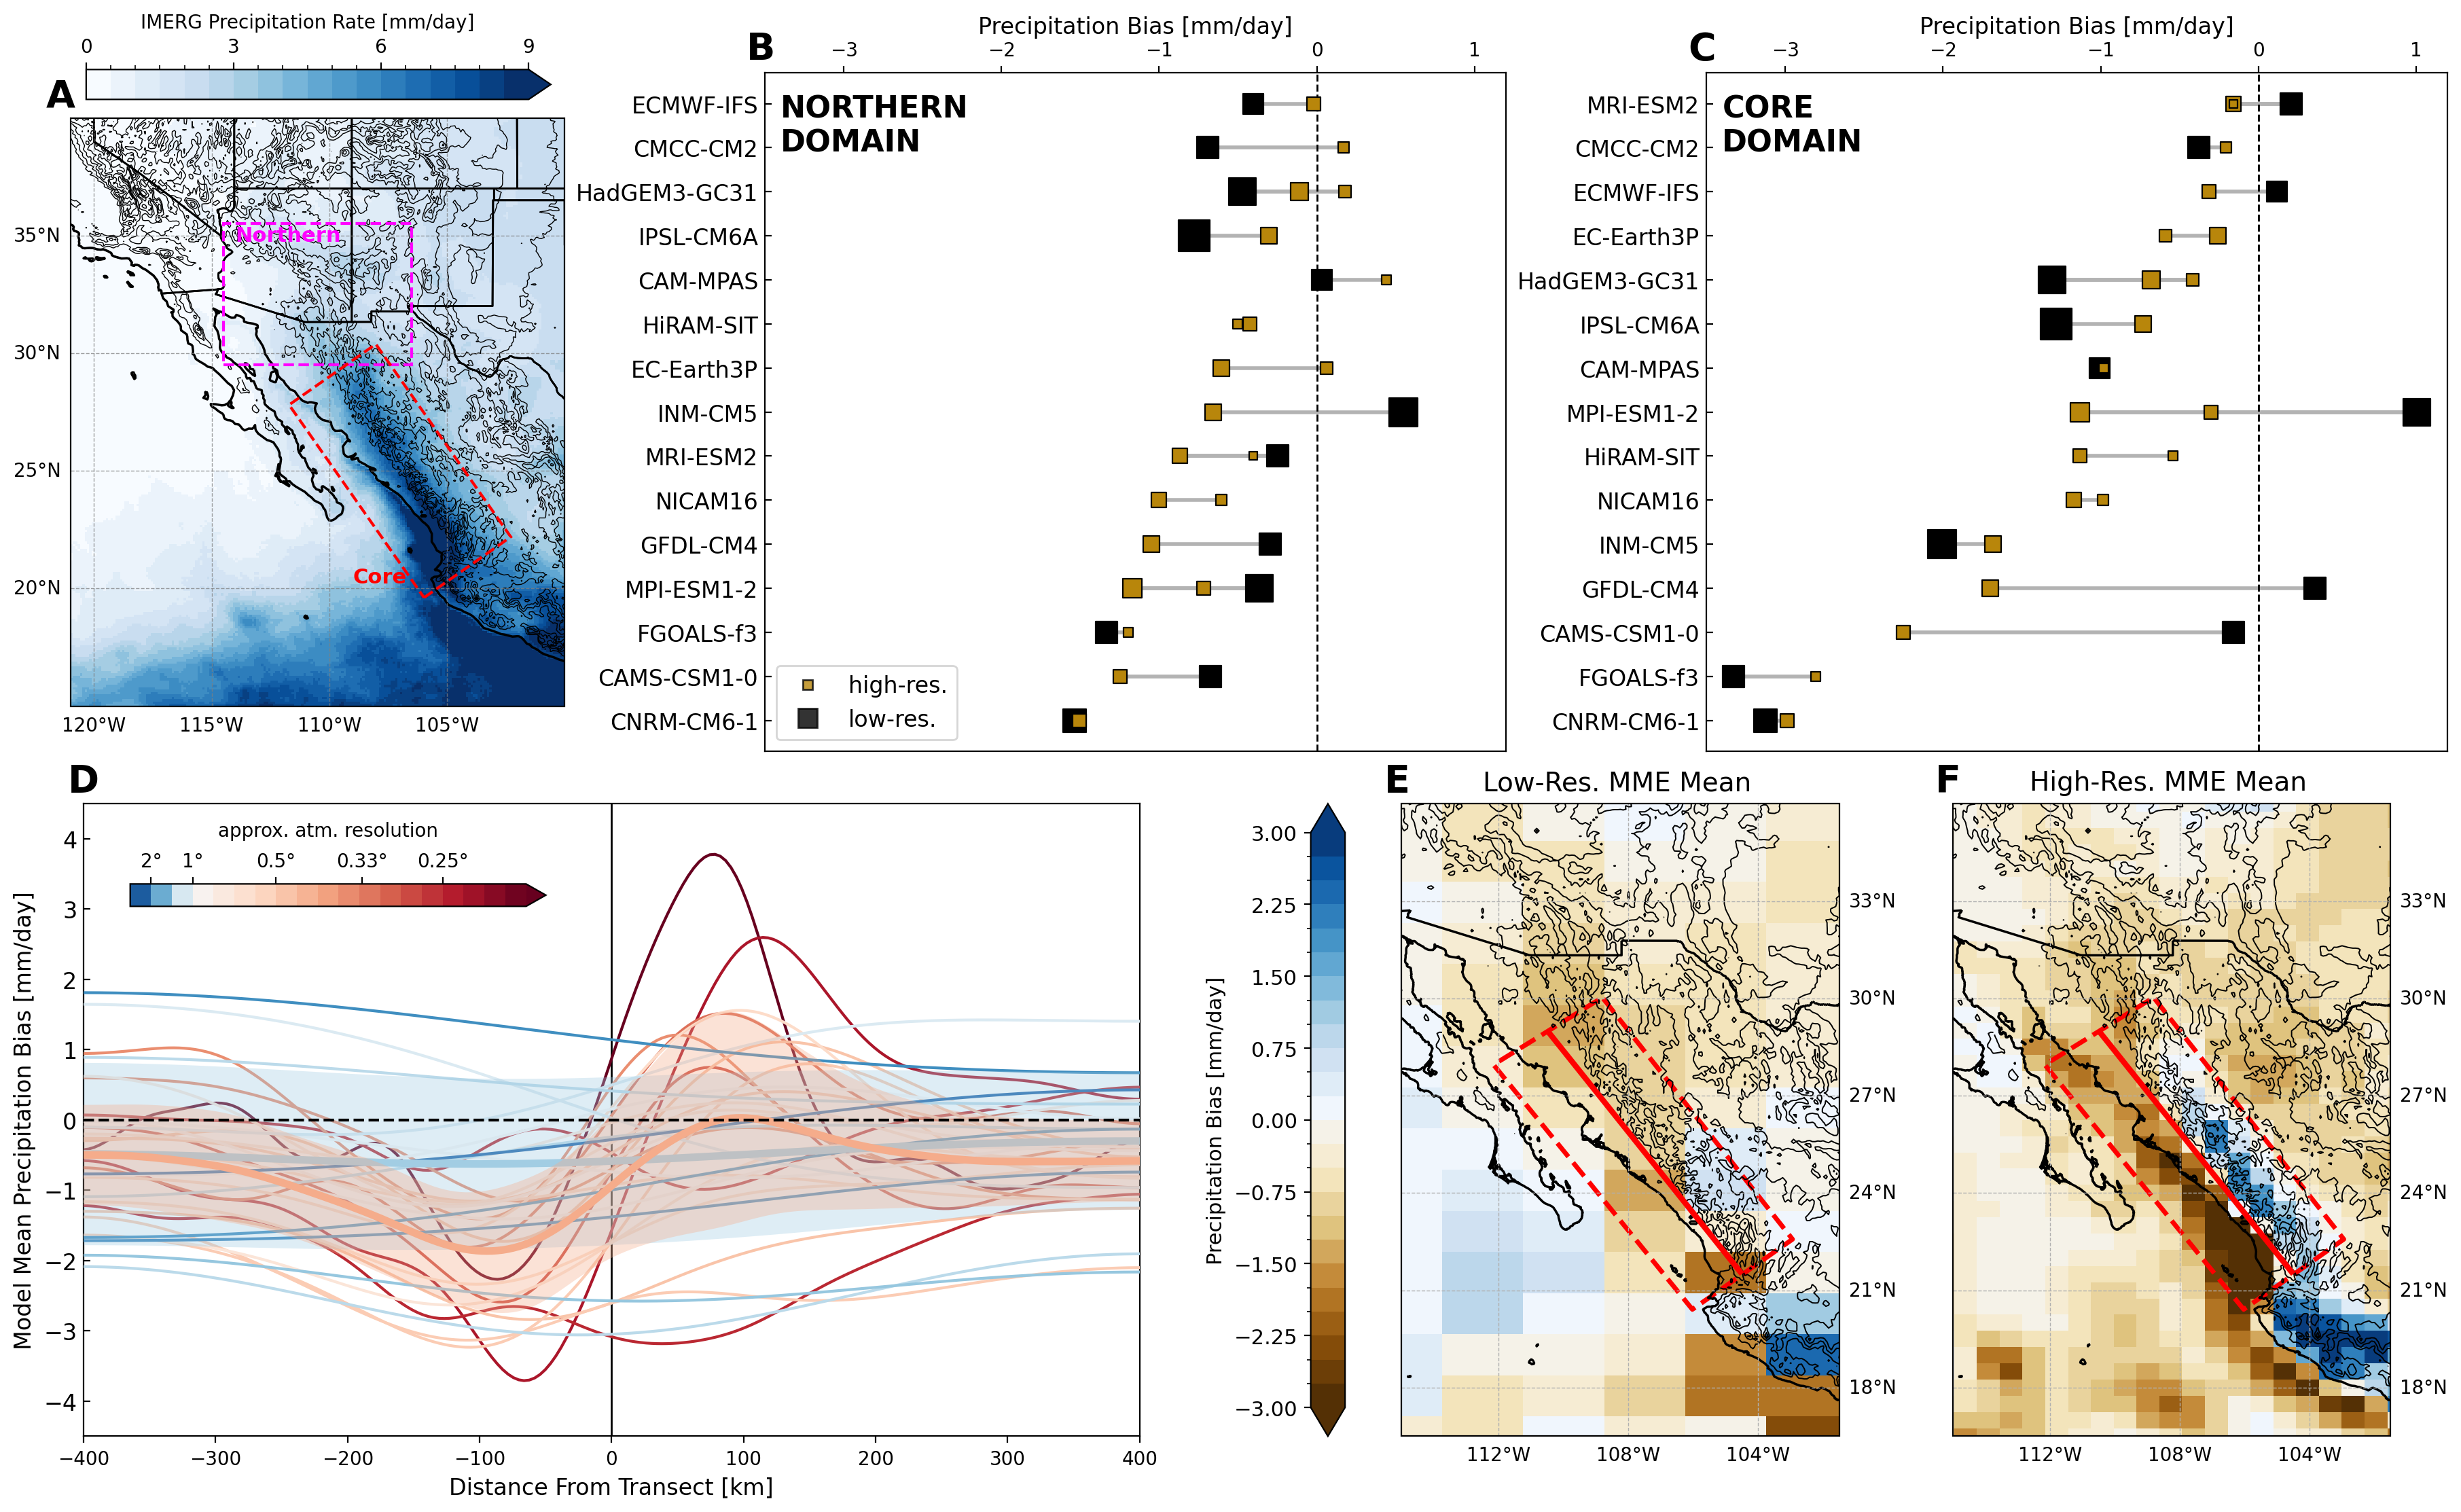

In [23]:
# choose which obs product to plot biases against
prod = 'imerg'

# settings
text_kw={'size':16, 'weight':'bold', 'color':'k', 'ha':'left', 'va':'center'}
text_kw_label = {'size':20, 'weight':'bold', 'color':'k'}
text_kw_sub = {'size':14, 'weight':'normal', 'color':'k', 'ha':'center', 'va':'bottom'}
line_kw={'ls':'-', 'lw':1.5, 'alpha':1}
tkw = {'axis':'y', 'direction':'in', 'labelsize':12} 
map_tkw={'color': 'black', 'weight': 'normal', 'size':10}
legend_kw={'loc':'lower left', 'bbox_to_anchor':(0,0), 'ncol':1, 'fontsize':12, 'labelcolor':'k', 'frameon':True}
legend_handles = [ Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='darkgoldenrod',
                       markersize=5, label='high-res.'),
                    Line2D([0], [0], marker='s', color='w', alpha=.8,
                       markeredgecolor='k', markerfacecolor='k',
                       markersize=10, label='low-res.') ]
# obs product colormap
pcmap,_,_,_=get_settings(field='precip', diff=False)
plevels=np.linspace(0, 9, 19)
pnorm=mpl.colors.BoundaryNorm(plevels, pcmap.N)
# prec bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dlevels=np.linspace(-3, 3, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# resolution colormap
cmap = cm.RdBu_r
vmin, vmax, vcenter = 90, 1800, 360
norm = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
levels = np.linspace(vmin, vmax, 20) 
# topography contours
zlevels=np.linspace(800,3200,5)
# map specs
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[245,258.5,16.5,36]

fig = plt.figure(figsize=(18, 11), constrained_layout=True)
gs0 = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 1], hspace=0.1)

top_gs = gs0[0].subgridspec(1, 3, width_ratios=[1, 1.5, 1.5], wspace=0)
ax1 = fig.add_subplot(top_gs[0], projection=proj)
ax2 = fig.add_subplot(top_gs[1])
ax3 = fig.add_subplot(top_gs[2])

bottom_gs = gs0[1].subgridspec(1, 5, width_ratios=[2, 0.05, 0.065, 1, 1], wspace=0)
ax4 = fig.add_subplot(bottom_gs[0])
trashax = fig.add_subplot(bottom_gs[1])
cax_bias = fig.add_subplot(bottom_gs[2])
ax5 = fig.add_subplot(bottom_gs[3], projection=proj)
ax6 = fig.add_subplot(bottom_gs[4], projection=proj)


#=== IMERG climatology with domain outlines
ax1.text(-0.05, 1.02, 'A', transform=ax1.transAxes, **text_kw_label)
cf = ax1.pcolormesh(jas_mean['obs'][prod].lon, jas_mean['obs'][prod].lat, jas_mean['obs'][prod], cmap=pcmap, norm=pnorm, transform=trans)
ax1.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=np.linspace(800,3800,7), linewidths=0.5, colors='k', transform=trans) # etopo05 contours
# add box around NAM sub-domains
poly1=patches.Polygon(coords_map['north'], closed=True, ec='magenta', fc='none', lw=1.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax1.add_patch(poly1)
poly2=patches.Polygon(coords_map['core'], closed=True, ec='red', fc='none', lw=1.5, ls='--', transform=ccrs.PlateCarree(), zorder=100); ax1.add_patch(poly2)
ax1.text(-114, 34.75,'Northern', color='magenta', fontsize=11, fontweight='bold')
ax1.text(-109, 20.25,'Core', color='red', fontsize=11, fontweight='bold')
# map formatting
ax1.coastlines(linewidth=1.25)
ax1.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1)
ax1.add_feature(cfeature.STATES, edgecolor='k', linewidth=1)
ax1.set_extent([239,260,15,40], crs=proj)
gl = ax1.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.75, linestyle='--')
gl.top_labels = False; gl.right_labels = False
gl.xlocator = plt.FixedLocator(range(-180, 181, 5))
gl.ylocator = plt.FixedLocator(range(-90, 91, 5))
# colorbar
cax=fig.add_axes([0.032, .94, 0.19, 0.02])
cbar=fig.colorbar(cf, ticks=np.linspace(0,9,4), orientation='horizontal', extend='max', cax=cax)
cbar.set_label('IMERG Precipitation Rate [mm/day]', labelpad=5, size=10, fontweight='normal', ha='center')
cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(labelsize=10)


#=== North Domain change in bias
ax2.text(-0.025, 1.02, 'B', transform=ax2.transAxes, **text_kw_label)
ax2.text(-3.4, 0.5, 'NORTHERN\nDOMAIN', **text_kw)
plot_panel_horizontal(ax2, 'north', 'bias')
ax2.set(xlim=[-3.5,1.2])
ax2.set_xlabel('Precipitation Bias [mm/day]', fontsize=12)
ax2.xaxis.set_label_position('top')
ax2.tick_params(**tkw)
ax2.legend(handles=legend_handles, **legend_kw)


#=== Core Domain change in bias
ax3.text(-0.025, 1.02, 'C', transform=ax3.transAxes, **text_kw_label)
ax3.text(-3.4, 0.5, 'CORE\nDOMAIN', **text_kw)
plot_panel_horizontal(ax3, 'core', 'bias')
ax3.set(xlim=[-3.5,1.2])
ax3.set_xlabel('Precipitation Bias [mm/day]', fontsize=12)
ax3.xaxis.set_label_position('top')
ax3.tick_params(**tkw)


#=== Transect Profiles
ax4.text(-0.015, 1.02, 'D', transform=ax4.transAxes, **text_kw_label)
ax4.axvline(x=0, color='k', lw=1, ls='-', label='_Hidden')
ax4.axhline(y=0, color='k', lw=1.5, ls='--', label='_Hidden', zorder=100)

for key, data in reversed(transect_profiles.items()):
    nlon = allmodels_res[key]
    color = cmap(norm(nlon))
    ax4.plot(data["bin_centers"], data["profile"], c=color, label=key, zorder=90, **line_kw)

lr_mean_nlon = 265.67
lr_color = cmap(norm(lr_mean_nlon))
ax4.plot(bin_centers, lr_mean, color=lr_color, lw=4, ls='-', zorder=95, label='LR MME')
ax4.fill_between(bin_centers, lr_mean-lr_std, lr_mean+lr_std, color=lr_color, edgecolor=None, alpha=0.35, zorder=95)

hr_mean_nlon = 892.76
hr_color = cmap(norm(hr_mean_nlon))
ax4.plot(bin_centers, hr_mean, color=hr_color, lw=4, ls='-', zorder=99,  label='HR MME')
ax4.fill_between(bin_centers, hr_mean-hr_std, hr_mean+hr_std, color=hr_color, edgecolor=None, alpha=0.35, zorder=99)

ax4.set_xlim([-buffer_km, buffer_km])
ax4.set_ylim([-4.5,4.5])
ax4.set_xlabel("Distance From Transect [km]", fontsize=12)
ax4.set_ylabel("Model Mean Precipitation Bias [mm/day]", fontsize=12)
ax4.tick_params(**tkw)

# model resolution, convert nlons to resolution (°) for tick labels
dlons = [2.0, 1.0, 0.5, 0.33, 0.25]
tick_nlons = [360.0 / d for d in dlons]

cax=fig.add_axes([0.05, .4, 0.17, 0.015])
sm = cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, boundaries=levels, ticks=tick_nlons, spacing="proportional",
                    extend='max',orientation='horizontal', cax=cax)
cbar.set_label("approx. atm. resolution", labelpad=-45, rotation=0)
cbar.ax.xaxis.set_ticks_position('top') 
cbar.set_ticklabels([f"{d:g}°" for d in dlons])


#=== Low-Res MME bias map
ax5.text(-0.04, 1.02, 'E', transform=ax5.transAxes, **text_kw_label)
ax5.text(-108.35,36.25,'Low-Res. MME Mean', **text_kw_sub)
cf_lr = ax5.pcolormesh(mme['lr'][prod].lon, mme['lr'][prod].lat, mme['lr'][prod],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax5.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7, colors='k', transform=trans)
ax5.add_geometries([transect_patch], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=2.5, ls='--')
ax5.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=3, zorder=100)
# map formatting
ax5.coastlines(color='k', linewidth=1.25)
ax5.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax5.set_extent(map_bnds, crs=trans)
gl=ax5.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw


#=== High-Res MME bias map
ax6.text(-0.04, 1.02,  'F', transform=ax6.transAxes, **text_kw_label)
ax6.text(-108.35,36.25,'High-Res. MME Mean', **text_kw_sub)
cf_hr = ax6.pcolormesh(mme['hr'][prod].lon, mme['hr'][prod].lat, mme['hr'][prod],
                       cmap=dcmap, norm=dnorm, transform=trans)
ax6.contour(etopoNA.lon, etopoNA.lat, etopoNA, levels=zlevels, linewidths=.7, colors='k', transform=trans)
ax6.add_geometries([transect_patch], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=2.5, ls='--')
ax6.add_geometries([transect_line], crs=ccrs.PlateCarree(),
                  facecolor='none', edgecolor='red', lw=3, zorder=100)    
# map formatting
ax6.coastlines(color='k', linewidth=1.25)
ax6.add_feature(cfeature.BORDERS, edgecolor='k', linewidth=1.25)
ax6.set_extent(map_bnds, crs=trans)
gl=ax6.gridlines(crs=trans, lw=.5, colors='black',linestyle='--', draw_labels=True)
gl.xlocator = mticker.MultipleLocator(4)
gl.ylocator = mticker.MultipleLocator(3)
gl.bottom_labels=True; gl.left_labels=False; gl.top_labels=False; gl.right_labels=True
gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# Precip bias colorbar
cbar = fig.colorbar(cf_hr, cax=cax_bias, orientation='vertical', extend='both')
cbar.set_label('Precipitation Bias [mm/day]', fontsize=11)
cbar.ax.yaxis.set_ticks_position('left')
cbar.ax.yaxis.set_label_position('left')
cbar.ax.tick_params(labelsize=11, rotation=0)

trashax.set_visible(False)

#plt.savefig(f'../figs/hrmip_pr_hist_mean_and_profiles_{prod}.png', transparent=False, bbox_inches='tight')
#plt.savefig(f'../figs/hrmip_pr_hist_mean_and_profiles_{prod}.pdf', transparent=False, bbox_inches='tight')

### Figure S1: Map of all HighResMIP models' historical biases

In [ ]:
# choose which obs product to plot biases against
prod = 'imerg'

# settings
text_kw={'color':'k', 'weight':'bold', 'size':16, 'ha':'center', 'va':'bottom'}
tx=-110
ty=40.5
# bias colormap
dcmap,_,_,_=get_settings(field='precip', diff=True)
dvmin=-3
dvmax=3
dlevels=np.linspace(dvmin, dvmax, 25)
dnorm=mpl.colors.BoundaryNorm(dlevels, dcmap.N)
# map specs
map_tkw={'color': 'black', 'weight': 'normal', 'size':9}
trans=ccrs.PlateCarree()
proj=ccrs.PlateCarree()
map_bnds=[239,260,15,40]

# Resolution bin thresholds and labels
n_bins = 3
res_bin_labels = ['$n_{lon}$ ≤ 360', '360 < $n_{lon}$ ≤ 720', '$n_{lon}$ > 720']

def get_res_bin(nlon):
    """Assign a config to resolution bin 0, 1, or 2 based on its lon grid size."""
    if nlon <= 360:
        return 0
    elif nlon <= 720:
        return 1
    else:
        return 2

families = list(lr_map.keys())

# Classify each config into a resolution bin using allmodels_res
cfg_to_bin = {cfg: get_res_bin(nlon) for cfg, nlon in allmodels_res.items()}

# For each (bin, family), collect all configs from lr_map and hr_map
bin_family_cfgs = {(b, family): [] for b in range(n_bins) for family in families}
for family in families:
    for cfg in lr_map[family] + hr_map[family]:
        if cfg in cfg_to_bin:
            bin_family_cfgs[(cfg_to_bin[cfg], family)].append(cfg)

# Each bin needs as many sub-rows as the max number of configs per family in that bin
max_rows_per_bin = [
    max(max(len(bin_family_cfgs[(b, f)]) for f in families), 1) for b in range(n_bins)
]
total_rows = sum(max_rows_per_bin)
bin_start_row = [sum(max_rows_per_bin[:b]) for b in range(n_bins)]
ncols = len(families)

fig, axes = plt.subplots(
    nrows=total_rows,
    ncols=ncols,
    figsize=(2.6*ncols, 3*total_rows),
    subplot_kw={'projection': proj},
    layout='constrained'
)

# --- First pass: place configs and set visibility ---
cf = None
for col, family in enumerate(families):
    for b in range(n_bins):
        cfgs = bin_family_cfgs[(b, family)]
        start_row = bin_start_row[b]

        for sub_i, cfg in enumerate(cfgs):
            row = start_row + sub_i
            ax = axes[row, col]
            da = allmodels[prod][cfg]
            cf = ax.pcolormesh(da.lon, da.lat, da, cmap=dcmap, norm=dnorm, transform=trans)
            ax.text(tx, ty, cfg, fontsize=9, ha='center')

        # Hide unused sub-rows within this bin for this family
        for sub_i in range(len(cfgs), max_rows_per_bin[b]):
            axes[start_row + sub_i, col].set_visible(False)

# --- Second pass: family column labels (first visible row per column) ---
for col, family in enumerate(families):
    for row in range(total_rows):
        if axes[row, col].get_visible():
            axes[row, col].set_title(family, fontsize=13, fontweight='bold', pad=4)
            break

# --- Third pass: resolution bin row labels (leftmost visible axis per bin) ---
for b in range(n_bins):
    for col in range(ncols):
        ax = axes[bin_start_row[b], col]
        if ax.get_visible():
            ax.set_ylabel(res_bin_labels[b], fontsize=11, fontweight='bold', labelpad=4)
            break

# --- Map formatting for all visible axes ---
for ax in axes.flat:
    if not ax.get_visible():
        continue

    poly1 = patches.Polygon(
        coords_map['north'],
        closed=True, ec='magenta', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=100
    )
    ax.add_patch(poly1)

    poly2 = patches.Polygon(
        coords_map['core'],
        closed=True, ec='red', fc='none', lw=2.5, ls='--',
        transform=ccrs.PlateCarree(), zorder=100
    )
    ax.add_patch(poly2)

    ax.coastlines(color='k', linewidth=.75)
    ax.add_feature(cfeature.STATES, linewidth=.75)
    ax.add_feature(cfeature.BORDERS, linewidth=.75)
    ax.set_extent(map_bnds, crs=trans)
    gl = ax.gridlines(crs=trans, lw=.5, linestyle='--', draw_labels=True)
    gl.bottom_labels=True; gl.left_labels=True; gl.top_labels=False; gl.right_labels=False
    gl.xformatter=LONGITUDE_FORMATTER; gl.yformatter=LATITUDE_FORMATTER
    gl.xlabel_style=map_tkw; gl.ylabel_style=map_tkw

# Colorbar
if cf is not None:
    cax = fig.add_axes([1.01, 0.1, 0.017, 0.8])
    cbar = fig.colorbar(cf, ticks=np.linspace(dvmin, dvmax, 13), orientation='vertical', extend='both', cax=cax)
    cbar.set_label('Precipitation Bias [mm/day]', labelpad=25, rotation=270, size=14, fontweight='normal', ha='center')
    cbar.ax.tick_params(labelsize=14)
    for tick in cbar.ax.yaxis.get_major_ticks():
        tick.label2.set_fontweight('normal')

#plt.savefig(f'../figs/hrmip_pr_bias_hist_maps_all_{prod}.png', transparent=False, bbox_inches='tight')
#plt.savefig(f'../figs/hrmip_pr_bias_hist_maps_all_{prod}.pdf', transparent=False, bbox_inches='tight')

### Figure SXX: Scatter plot 